In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
TRAIN_PATH='/kaggle/input/competitions/dog-breed-identification/train/'
TEST_PATH='/kaggle/input/competitions/dog-breed-identification/test/'

In [3]:
df = pd.read_csv('/kaggle/input/competitions/dog-breed-identification/labels.csv')

In [4]:
df.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [5]:
from PIL import Image

In [6]:
df['id'].iloc[0]

'000bec180eb18c7604dcecc8fe0dba07'

Breed -  golden_retriever


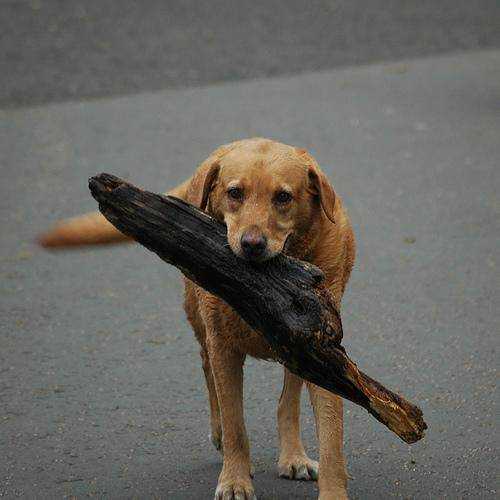

In [7]:
print("Breed - ", df['breed'].iloc[4])
Image.open(TRAIN_PATH+df['id'].iloc[4]+'.jpg')

In [8]:
df.shape, len(df['breed'].unique())

((10222, 2), 120)

In [9]:
import matplotlib.pyplot as plt
import cv2 as cv

In [10]:
img_path = TRAIN_PATH+df['id'].iloc[0]+'.jpg'

(375, 500, 3)


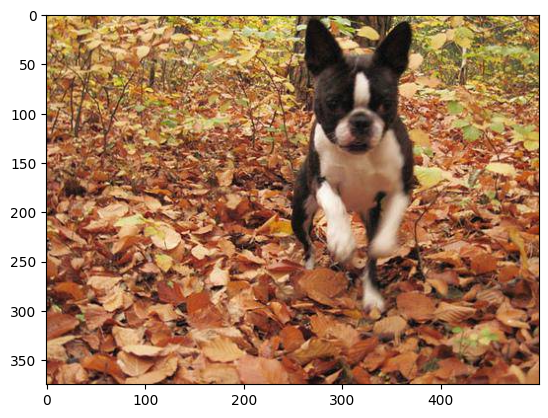

In [11]:
# img = cv.imread(img_path)[:,:,::-1] # array[start : stop : step]
# img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img = cv.imread(img_path)[:, ::-1, ::-1] # flip image and then change bgr to rgb
print(img.shape)
plt.imshow(img)
plt.show()
# img[::-1, :, :] → reverse rows → vertical flip
# img[:, ::-1, :] → reverse columns → horizontal flip
# img[:, :, ::-1] → reverse channels → BGR → RGB conversion

In [12]:
# use ImageDataGenerator from keras

In [13]:
# WORKING_DIR='/kaggle/working/'
# AUG_TRAIN_PATH='/kaggle/working/train/'
# AUG_TEST_PATH='/kaggle/working/train/'
# if not os.path.exists(AUG_TRAIN_PATH):
#     os.mkdir(AUG_TRAIN_PATH)
# if not os.path.exists(AUG_TEST_PATH):
#     os.mkdir(AUG_TEST_PATH)

In [14]:
df.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [15]:
df['img_path'] = df['id'].apply(lambda x: TRAIN_PATH+x+'.jpg')

In [16]:
df.head()

,id,breed,img_path
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull,/kaggle/input/competitions/dog-breed-identific...
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo,/kaggle/input/competitions/dog-breed-identific...
2,001cdf01b096e06d78e9e5112d419397,pekinese,/kaggle/input/competitions/dog-breed-identific...
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick,/kaggle/input/competitions/dog-breed-identific...
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever,/kaggle/input/competitions/dog-breed-identific...


In [17]:
df.shape, df[df['breed'] == 'boston_bull'].shape, df.shape[0]

((10222, 3), (87, 3), 10222)

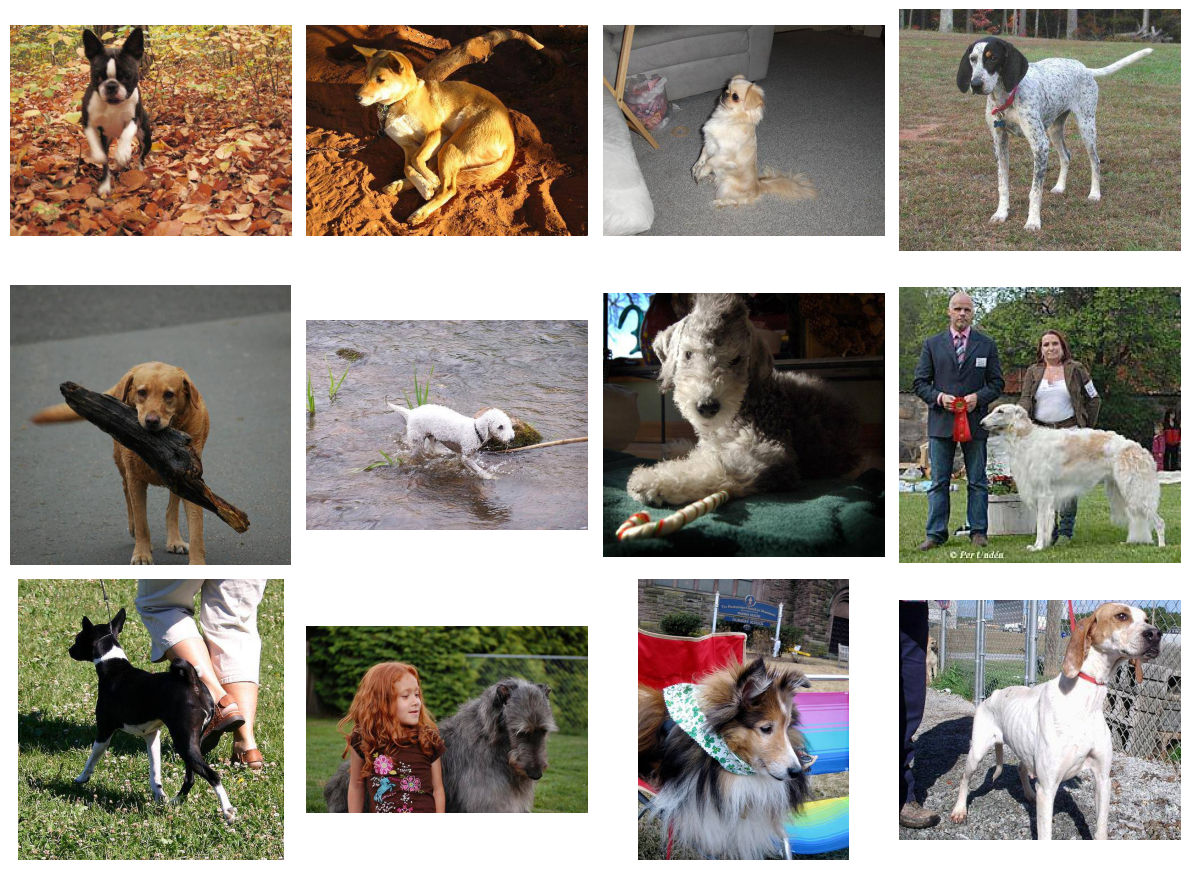

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

image_paths = df["img_path"].iloc[:12]

for ax, img_path in zip(axes.flat, image_paths):
    img = cv.imread(img_path)

    if img is not None:
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        ax.imshow(img)

    ax.axis("off")

plt.tight_layout()
plt.show()

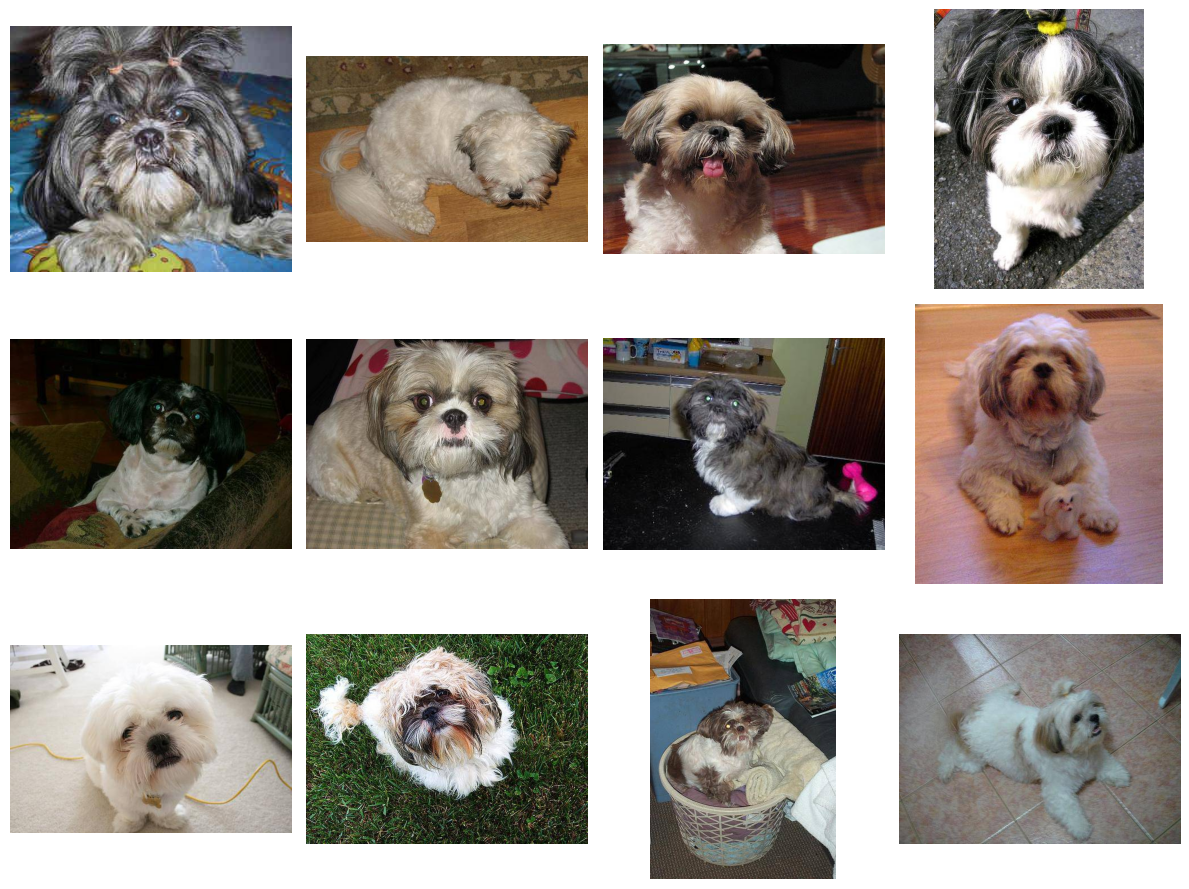

In [19]:
# only golden_retriever
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
image_paths = df[df['breed'] == 'shih-tzu']["img_path"].iloc[:12]

for ax, img_path in zip(axes.flat, image_paths):
    img = cv.imread(img_path)

    if img is not None:
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        ax.imshow(img)

    ax.axis("off")

plt.tight_layout()
plt.show()

In [20]:
import torch
from torchvision import transforms
from torchvision import models
from torch.utils.data import Dataset

In [21]:
class DogBreedDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

        breeds = sorted(df["breed"].unique())
        self.breed_to_idx = {
            breed: idx for idx, breed in enumerate(breeds)
        }
        self.idx_to_breed = {
            idx: breed for breed, idx in self.breed_to_idx.items()
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["img_path"]).convert("RGB")
        label = self.breed_to_idx[row["breed"]]

        if self.transform:
            img = self.transform(img)

        return img, label

In [22]:
class DogBreedTestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.image_paths = sorted([
            os.path.join(root_dir, img)
            for img in os.listdir(root_dir)
            if os.path.isfile(os.path.join(root_dir, img))
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        image_id = os.path.splitext(os.path.basename(img_path))[0]

        return img, image_id

In [23]:
IMG_DIM=224

In [24]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_DIM, IMG_DIM)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_DIM, IMG_DIM)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])
test_transform = transforms.Compose([
    transforms.Resize((IMG_DIM, IMG_DIM)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [25]:
from torch.utils.data import random_split

In [26]:
indices = np.random.permutation(len(df))
indices

array([6549, 7447, 2853, ..., 6656, 2646, 9101], shape=(10222,))

In [27]:
train_size = int(0.85 * len(df))

train_idx = indices[:train_size]
val_idx = indices[train_size:]

In [28]:
train_idx.shape, val_idx.shape

((8688,), (1534,))

In [29]:
train_df = df.iloc[indices[:train_size]].reset_index(drop=True)
val_df = df.iloc[indices[train_size:]].reset_index(drop=True)
train_df.shape, val_df.shape

((8688, 3), (1534, 3))

In [30]:
train_dataset = DogBreedDataset(train_df, train_transform)
val_dataset = DogBreedDataset(val_df, val_transform)
test_dataset = DogBreedTestDataset(TEST_PATH, transform=test_transform)

In [31]:
len(train_dataset), len(val_dataset), len(test_dataset)

(8688, 1534, 10357)

In [32]:
train_dataset.breed_to_idx == val_dataset.breed_to_idx

True

In [33]:
def show_image(img_tensor):
    # Convert C,H,W -> H,W,C
    img = img_tensor.permute(1, 2, 0)

    # If normalized with mean=std=0.5
    img = img * 0.5 + 0.5

    img = torch.clamp(img, 0, 1)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

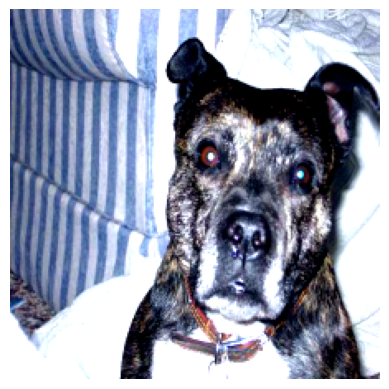

In [34]:
test_img_path = os.listdir(TEST_PATH)[0]

img = Image.open(
    os.path.join(TEST_PATH, test_img_path)
).convert("RGB")

img_tensor = test_transform(img)
show_image(img_tensor)

In [35]:
batch_size=32

In [36]:
from torch.utils.data import DataLoader

In [37]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [38]:
images, labels = next(iter(train_loader))
print(images.shape)

torch.Size([32, 3, 224, 224])


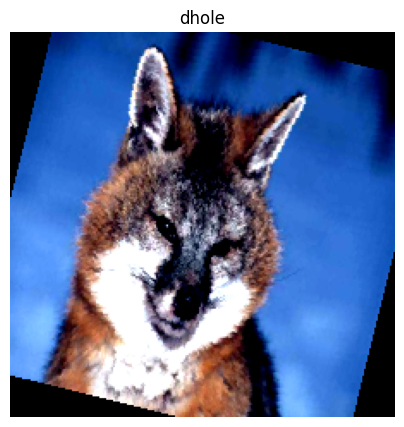

In [39]:
images, labels = next(iter(train_loader))

image = images[0] * 0.5 + 0.5
label = labels[0]

plt.figure(figsize=(5, 5))
plt.imshow(image.permute(1, 2, 0).clamp(0, 1))
plt.title(train_dataset.idx_to_breed[label.item()])
plt.axis("off")
plt.show()

In [40]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [41]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 242MB/s]


In [42]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [43]:
import torch.nn as nn

In [44]:
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 120)

In [45]:
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 120)

In [46]:
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

In [47]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.downsample.0.weight
layer3.0.downsample.1.weight
layer3.0.downsample.1.bias
layer3.1.conv1.weight
layer3.1.bn1.weight
layer3.1.bn1.bias
layer3.1.conv2.weight
layer3.1.bn2.weight
layer3.1.bn2.bias
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


In [48]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable: {trainable:,}")
print(f"Total: {total:,}")

Trainable: 10,555,000
Total: 11,238,072


In [49]:
import torch.optim as optim

In [50]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p:p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

In [51]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [52]:
epochs = 20
best_val_loss = float("inf")
patience = 5
counter = 0

In [53]:
for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # val
    model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

            total += labels.size(0)

    val_loss /= len(val_loader)
    accuracy = correct / total
    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {accuracy:.2f}%"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(
            model.state_dict(),
            "best_resnet18.pth"
        )

    else:
        counter += 1

    if counter >= patience:
        print("Early Stopping")
        break

Epoch [1/20] Train Loss: 3.1172 Val Loss: 1.8902 Val Acc: 0.59%
Epoch [2/20] Train Loss: 1.6372 Val Loss: 1.4192 Val Acc: 0.64%
Epoch [3/20] Train Loss: 1.1247 Val Loss: 1.2085 Val Acc: 0.67%
Epoch [4/20] Train Loss: 0.8168 Val Loss: 1.1212 Val Acc: 0.69%
Epoch [5/20] Train Loss: 0.6058 Val Loss: 1.1074 Val Acc: 0.68%
Epoch [6/20] Train Loss: 0.4637 Val Loss: 1.0486 Val Acc: 0.71%
Epoch [7/20] Train Loss: 0.3197 Val Loss: 1.0796 Val Acc: 0.70%
Epoch [8/20] Train Loss: 0.2453 Val Loss: 1.0817 Val Acc: 0.70%
Epoch [9/20] Train Loss: 0.1892 Val Loss: 1.0641 Val Acc: 0.69%
Epoch [10/20] Train Loss: 0.1103 Val Loss: 1.0242 Val Acc: 0.71%
Epoch [11/20] Train Loss: 0.0900 Val Loss: 1.0187 Val Acc: 0.71%
Epoch [12/20] Train Loss: 0.0809 Val Loss: 1.0443 Val Acc: 0.71%
Epoch [13/20] Train Loss: 0.0674 Val Loss: 1.0497 Val Acc: 0.72%
Epoch [14/20] Train Loss: 0.0578 Val Loss: 1.0499 Val Acc: 0.72%
Epoch [15/20] Train Loss: 0.0483 Val Loss: 1.0473 Val Acc: 0.71%
Epoch [16/20] Train Loss: 0.0398 V

In [54]:
PATH = './dog_breed.pt'
torch.save(model.state_dict(), PATH)

In [64]:
model.load_state_dict(
    torch.load(
        "/kaggle/working/best_resnet18.pth",
        map_location=device
    )
)

model = model.to(device)

In [65]:
model.eval()
correct, total = 0,0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct/total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 0.71%


In [66]:
model.eval()

with torch.no_grad():
    images, labels = next(iter(val_loader))
    images = images.to(device)

    outputs = model(images)

    probs = torch.softmax(outputs, dim=1)

    confidence, preds = probs.max(dim=1)

    preds = preds.cpu()
    confidence = confidence.cpu()

    for i in range(min(10, len(labels))):
        print(
            f"Confidence={confidence[i]:.3f}, "
            f"Pred={train_dataset.idx_to_breed[preds[i].item()]}, "
            f"Label={val_dataset.idx_to_breed[labels[i].item()]}"
        )

Confidence=0.259, Pred=staffordshire_bullterrier, Label=staffordshire_bullterrier
Confidence=0.629, Pred=great_pyrenees, Label=great_pyrenees
Confidence=0.972, Pred=bernese_mountain_dog, Label=bernese_mountain_dog
Confidence=0.130, Pred=bedlington_terrier, Label=ibizan_hound
Confidence=0.983, Pred=irish_wolfhound, Label=irish_wolfhound
Confidence=0.918, Pred=lakeland_terrier, Label=lakeland_terrier
Confidence=0.400, Pred=wire-haired_fox_terrier, Label=lakeland_terrier
Confidence=0.909, Pred=sussex_spaniel, Label=sussex_spaniel
Confidence=0.930, Pred=scottish_deerhound, Label=scottish_deerhound
Confidence=0.812, Pred=shetland_sheepdog, Label=shetland_sheepdog


In [57]:
# net = Network().to(device)
# net.load_state_dict(torch.load("best_model.pth", map_location=device))
# net.eval()

In [58]:
predictions = []
image_ids = []

with torch.no_grad():
    for imgs, ids in test_loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)

        predictions.extend(probs.cpu().numpy())
        image_ids.extend(ids)

In [59]:
preds = np.vstack(predictions)

In [60]:
breed_cols = list(train_dataset.dataset.breed_to_idx.keys()) \
    if hasattr(train_dataset, "dataset") else list(train_dataset.breed_to_idx.keys())
breed_cols[:5]

['affenpinscher',
 'afghan_hound',
 'african_hunting_dog',
 'airedale',
 'american_staffordshire_terrier']

In [61]:
submission = pd.DataFrame(preds, columns=breed_cols)
submission.insert(0, "id", image_ids)

In [62]:
submission.head()

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,000621fb3cbb32d8935728e48679680e,0.000014,0.000029,0.000005,0.000002,0.000012,0.000007,0.000002,0.000005,0.000005,...,0.000013,0.000120,0.000003,0.000020,0.000007,0.000009,0.000004,0.000010,0.000008,0.000001
1,00102ee9d8eb90812350685311fe5890,0.000003,0.000001,0.000001,0.000002,0.000005,0.000006,0.000002,0.000005,0.000006,...,0.000006,0.000012,0.000006,0.000021,0.000002,0.000007,0.000015,0.000004,0.000004,0.000004
2,0012a730dfa437f5f3613fb75efcd4ce,0.000143,0.001781,0.000160,0.000107,0.000165,0.000032,0.000146,0.000064,0.000579,...,0.000041,0.000022,0.000517,0.000120,0.006564,0.005165,0.000239,0.000136,0.000070,0.000047
3,001510bc8570bbeee98c8d80c8a95ec1,0.003244,0.011529,0.001671,0.001829,0.003409,0.001281,0.000746,0.003732,0.003343,...,0.006448,0.000260,0.003604,0.001498,0.012451,0.004362,0.000328,0.029513,0.000783,0.005861
4,001a5f3114548acdefa3d4da05474c2e,0.015621,0.000429,0.000197,0.000153,0.000214,0.000655,0.001872,0.000174,0.000177,...,0.000312,0.000162,0.000106,0.000507,0.000188,0.000156,0.000382,0.000215,0.000709,0.002679


In [63]:
submission.to_csv("submission.csv", index=False)